In [21]:
# importing libraries
import pandas as pd
import numpy as np

In [22]:
#loading dataset
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head() 


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
#selecting useful columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch']]
df.head()

,Survived,Pclass,Sex,Age,Fare,SibSp,Parch
0,0,3,male,22.0,7.2500,1,0
1,1,1,female,38.0,71.2833,1,0
2,1,3,female,26.0,7.9250,0,0
3,1,1,female,35.0,53.1000,1,0
4,0,3,male,35.0,8.0500,0,0


In [24]:
#handling the missing ages(means NAN) with the median using fillna...
df['Age'] = df['Age'].fillna(df['Age'].median())

In [25]:
# converting male/female into number so that the model can use it...
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [26]:
# seperating input columns and outputs...

from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

#   80% train /  20% test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)


In [27]:
# scale the numeric feature

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [28]:
#creating model and train it on the scaled data

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
# generate prediction by using model
pred = lr.predict(X_test_scaled)


In [30]:
# calculate the accuracy of model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, pred)
accuracy


0.770949720670391

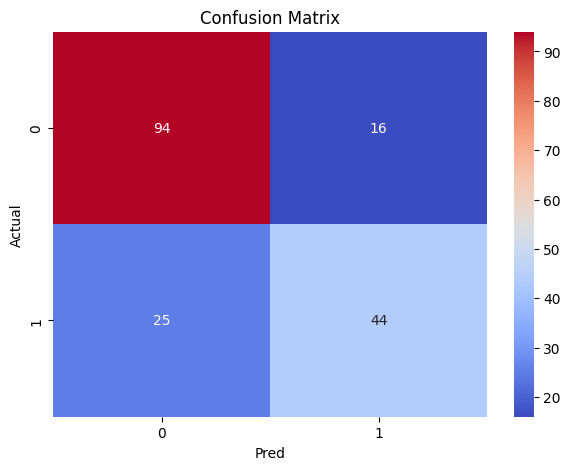

In [31]:
# confusion matrix 

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

matrix = confusion_matrix(y_test, pred)

plt.figure(figsize=(7,5))
sns.heatmap(matrix, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix")
plt.xlabel("Pred")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.show()

